# 📘 Deep Learning Text Generation — Detailed Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This is the **expanded, detailed edition** of the original notebook. It keeps the same core pipeline (tokenize → build sequences → train RNN/LSTM/GRU → generate text) and adds the analysis a deeper learning project usually needs: parameter and timing comparisons, perplexity, temperature-based sampling, embedding-space visualization, and next-word probability inspection.

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus, understand *why* gated architectures perform better, and see that difference quantitatively — not just by eyeballing generated sentences.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss & accuracy
- model size (parameter count) and training time
- perplexity (how "confident" each model is)
- generated text quality, including with temperature-based sampling
- what each model actually learned, visualized in embedding space

# 🗺️ What's in this notebook
1. Setup & imports
2. Load and explore the text corpus
3. Tokenization & sequence creation
4. Helper functions (timing, embedding extraction)
5. Build & train: Vanilla RNN, LSTM, GRU
6. Compare training loss & accuracy
7. Compare model complexity (parameters) & training time
8. Perplexity — a proper language-model metric
9. Text generation: greedy decoding
10. Text generation: temperature-based sampling
11. Embedding space visualization (PCA)
12. Inspect next-word probabilities
13. Save trained models
14. Student learning tasks & conclusion

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
import time

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We start with the same **small built-in sample corpus** so this still runs in seconds. A toggle right after it lets you switch to a slightly **richer corpus** with more vocabulary and longer sentences, which tends to produce more interesting generated text.

You can later replace either one with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF-extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



In [3]:
# Toggle this to True to train on a larger, more varied corpus instead.
# Bigger vocabulary + longer sentences usually means more meaningful generated text,
# at the cost of needing more epochs to fit well.
USE_EXTENDED_CORPUS = False

extended_corpus = '''
deep learning is transforming artificial intelligence across every industry
recurrent neural networks are useful for sequential data like text and speech
lstm helps remember long term dependencies that simple rnn models tend to forget
gru is faster and simpler than lstm while still handling long range context well
text generation models predict the next word based on everything that came before
deep learning models can generate meaningful sentences when trained on enough data
attention mechanisms and transformers have since replaced rnns in most modern systems
but understanding rnn lstm and gru is still the best way to learn how sequence models work
'''

corpus = extended_corpus if USE_EXTENDED_CORPUS else corpus
print("Using:", "extended corpus" if USE_EXTENDED_CORPUS else "original corpus")
print(corpus)

Using: original corpus

deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔍 Explore the Corpus
Before tokenizing, it helps to actually look at the data: how many words total, how many unique words, and which ones show up most often.

Total words in corpus: 41
Unique words: 36

Top words by frequency:
  deep: 2
  learning: 2
  is: 2
  lstm: 2
  models: 2
  transforming: 1
  artificial: 1
  intelligence: 1
  recurrent: 1
  neural: 1


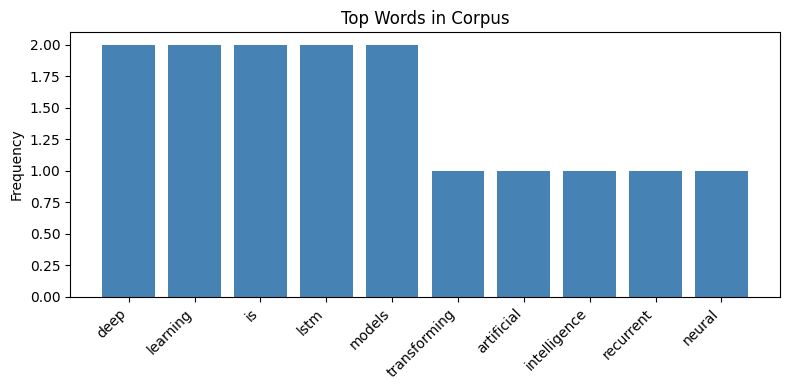

In [4]:
words = corpus.split()
word_freq = Counter(words)
most_common = word_freq.most_common(10)

print("Total words in corpus:", len(words))
print("Unique words:", len(set(words)))
print("\nTop words by frequency:")
for word, count in most_common:
    print(f"  {word}: {count}")

plt.figure(figsize=(8,4))
labels, counts = zip(*most_common)
plt.bar(labels, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.title("Top Words in Corpus")
plt.tight_layout()
plt.show()

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


## 👀 Sanity-check a few examples
It's worth decoding a couple of rows back into words to confirm the (input → next word) pairs make sense before training anything.

In [6]:
print("Example sequences (input -> target word):\n")
for i in [0, 1, len(X)//2, len(X)-1]:
    input_words = [tokenizer.index_word.get(idx, '') for idx in X[i] if idx != 0]
    target_word = tokenizer.index_word.get(y[i], '')
    print(f"  {' '.join(input_words):<45} -> {target_word}")

Example sequences (input -> target word):

  deep                                          -> learning
  deep learning                                 -> is
  gru                                           -> is
  deep learning models can generate meaningful  -> sentences


# 🧰 Helper Functions
Two small utilities used throughout the rest of the notebook:
- `train_and_time` — trains a model and records wall-clock training time
- `get_embedding_weights` — pulls the learned embedding matrix out of a model, used later for visualization

We also define one `EarlyStopping` config that all three models will use, so the comparison is fair: nobody trains for extra free epochs.

In [7]:
def train_and_time(model, X, y, epochs=150, callbacks=None, verbose=0):
    """Train a model and return its history plus wall-clock training time."""
    start = time.time()
    history = model.fit(X, y, epochs=epochs, callbacks=callbacks, verbose=verbose)
    elapsed = time.time() - start
    return history, elapsed

def get_embedding_weights(model):
    """Pull the learned embedding matrix out of a model, regardless of layer position."""
    for layer in model.layers:
        if isinstance(layer, Embedding):
            return layer.get_weights()[0]
    raise ValueError("No Embedding layer found in model")

def make_early_stop():
    return EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [8]:
rnn_model = Sequential([
    Input(shape=(max_len-1,)),
    Embedding(total_words, 32),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

rnn_history, rnn_time = train_and_time(rnn_model, X, y, epochs=150, callbacks=[make_early_stop()])
print(f"\nVanilla RNN training completed in {rnn_time:.2f}s over {len(rnn_history.history['loss'])} epochs")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,797 (38.27 KB)

 Trainable params: 9,797 (38.27 KB)

 Non-trainable params: 0 (0.00 B)


Vanilla RNN training completed in 11.91s over 150 epochs


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [9]:
lstm_model = Sequential([
    Input(shape=(max_len-1,)),
    Embedding(total_words, 32),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

lstm_history, lstm_time = train_and_time(lstm_model, X, y, epochs=150, callbacks=[make_early_stop()])
print(f"\nLSTM training completed in {lstm_time:.2f}s over {len(lstm_history.history['loss'])} epochs")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,421 (111.02 KB)

 Trainable params: 28,421 (111.02 KB)

 Non-trainable params: 0 (0.00 B)


LSTM training completed in 6.96s over 150 epochs


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [10]:
gru_model = Sequential([
    Input(shape=(max_len-1,)),
    Embedding(total_words, 32),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model.summary()

gru_history, gru_time = train_and_time(gru_model, X, y, epochs=150, callbacks=[make_early_stop()])
print(f"\nGRU training completed in {gru_time:.2f}s over {len(gru_history.history['loss'])} epochs")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,405 (87.52 KB)

 Trainable params: 22,405 (87.52 KB)

 Non-trainable params: 0 (0.00 B)


GRU training completed in 8.07s over 150 epochs


## 📉 Compare Training Loss

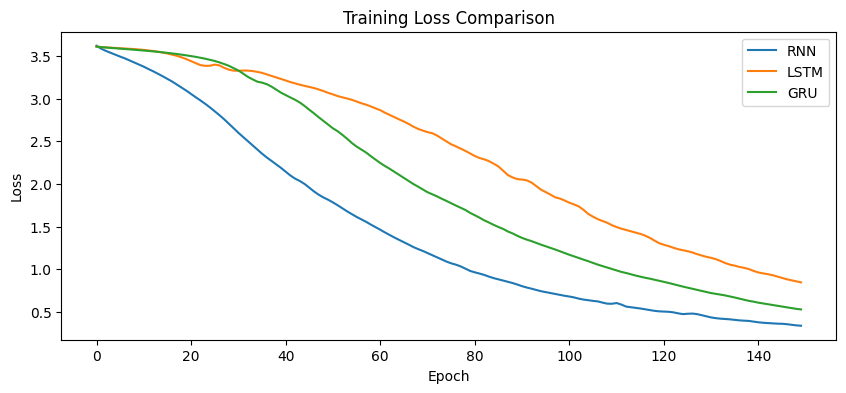

In [11]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## 📊 Compare Training Accuracy

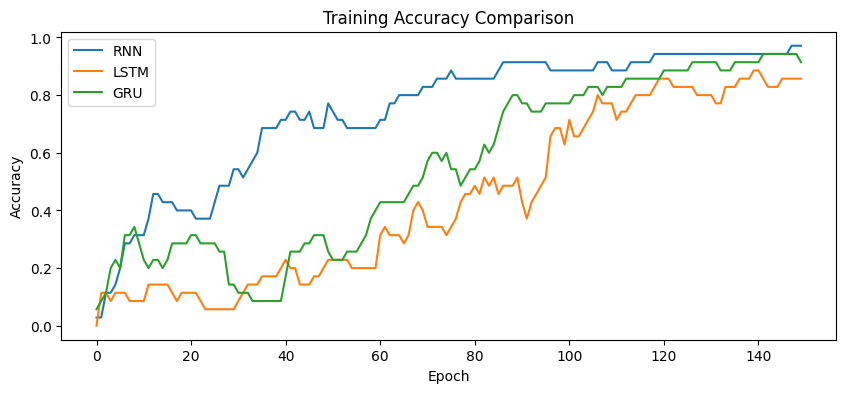

In [12]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# ⚖️ Compare Model Complexity & Training Time
Loss curves only tell part of the story. LSTM and GRU have more trainable parameters per unit than a SimpleRNN (LSTM ≈ 4x, GRU ≈ 3x the gate parameters), so it's worth seeing that cost directly alongside how long each one took to train.

    Model  Parameters  Final Loss  Final Accuracy  Training Time (s)  Epochs Run
SimpleRNN        9797    0.338261        0.971429          11.910933         150
     LSTM       28421    0.846523        0.857143           6.960406         150
      GRU       22405    0.529451        0.914286           8.066676         150


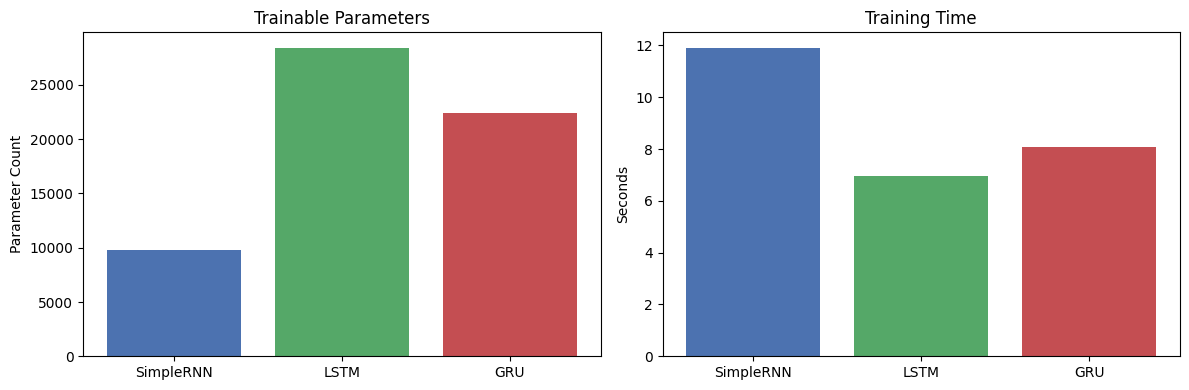

In [13]:
model_stats = pd.DataFrame({
    'Model': ['SimpleRNN', 'LSTM', 'GRU'],
    'Parameters': [rnn_model.count_params(), lstm_model.count_params(), gru_model.count_params()],
    'Final Loss': [rnn_history.history['loss'][-1], lstm_history.history['loss'][-1], gru_history.history['loss'][-1]],
    'Final Accuracy': [rnn_history.history['accuracy'][-1], lstm_history.history['accuracy'][-1], gru_history.history['accuracy'][-1]],
    'Training Time (s)': [rnn_time, lstm_time, gru_time],
    'Epochs Run': [len(rnn_history.history['loss']), len(lstm_history.history['loss']), len(gru_history.history['loss'])]
})

print(model_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(model_stats['Model'], model_stats['Parameters'], color=colors)
axes[0].set_title("Trainable Parameters")
axes[0].set_ylabel("Parameter Count")

axes[1].bar(model_stats['Model'], model_stats['Training Time (s)'], color=colors)
axes[1].set_title("Training Time")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

# 📐 Perplexity
Accuracy and loss are useful, but **perplexity** is the standard metric for language models: it's `exp(cross-entropy loss)`, roughly interpreted as "how many words the model was effectively choosing between" at each prediction step. A perplexity of 1 means the model was completely certain every time; higher numbers mean more uncertainty.

On a corpus this small, all three models will likely memorize it and show very low perplexity — that's expected, and is itself a useful observation about overfitting on tiny datasets.

In [14]:
def compute_perplexity(model, X, y):
    loss, _ = model.evaluate(X, y, verbose=0)
    return np.exp(loss)

rnn_ppl = compute_perplexity(rnn_model, X, y)
lstm_ppl = compute_perplexity(lstm_model, X, y)
gru_ppl = compute_perplexity(gru_model, X, y)

print(f"RNN  perplexity: {rnn_ppl:.3f}")
print(f"LSTM perplexity: {lstm_ppl:.3f}")
print(f"GRU  perplexity: {gru_ppl:.3f}")

RNN  perplexity: 1.400
LSTM perplexity: 2.308
GRU  perplexity: 1.688


# ✍️ Text Generation: Greedy Decoding
This function predicts the next word repeatedly by always picking the single most likely word — the same approach as the original notebook, just using `tokenizer.index_word` instead of looping over the whole vocabulary each time.

In [15]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = tokenizer.index_word.get(predicted, "")
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples (Greedy)

In [16]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is transforming artificial intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 🌡️ Text Generation: Temperature-Based Sampling
Greedy decoding always picks the top word, which can make text repetitive or get stuck in loops — especially with such a small vocabulary. **Temperature sampling** instead treats the model's output as a probability distribution and samples from it:

- **Low temperature (e.g. 0.2)** → sharper distribution, close to greedy, more predictable
- **Temperature = 1.0** → samples exactly according to the model's learned probabilities
- **High temperature (e.g. 1.5)** → flatter distribution, more random, more "creative" (and more likely to go off the rails on a tiny corpus)

In [17]:
def generate_text_temperature(model, seed_text, next_words=5, temperature=1.0):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        preds = model.predict(token_list, verbose=0)[0].astype('float64')

        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        predicted_index = np.random.choice(len(preds), p=preds)
        output_word = tokenizer.index_word.get(predicted_index, "")
        seed_text += " " + output_word
    return seed_text

## 🎲 Compare Generation at Different Temperatures

In [18]:
seed = "deep learning"
temperatures = [0.2, 0.7, 1.0, 1.5]
models = {'RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}

for name, model in models.items():
    print(f"--- {name} ---")
    for temp in temperatures:
        text = generate_text_temperature(model, seed, next_words=6, temperature=temp)
        print(f"  temperature={temp}: {text}")
    print()

--- RNN ---
  temperature=0.2: deep learning models can generate meaningful sentences data
  temperature=0.7: deep learning models can generate meaningful sentences data
  temperature=1.0: deep learning long transforming generate the sentences text
  temperature=1.5: deep learning is transforming next word sentences gru

--- LSTM ---
  temperature=0.2: deep learning is transforming artificial intelligence than lstm
  temperature=0.7: deep learning models generate generate meaningful sentences sentences
  temperature=1.0: deep learning neural networks artificial generate simpler lstm
  temperature=1.5: deep learning deep is artificial and intelligence neural

--- GRU ---
  temperature=0.2: deep learning is transforming artificial intelligence intelligence intelligence
  temperature=0.7: deep learning is transforming artificial intelligence intelligence next
  temperature=1.0: deep learning models faster next word generation word
  temperature=1.5: deep learning models transforming sente

# 🗺️ Word Embedding Visualization
Each model learns its own 32-dimensional embedding for every word in the vocabulary. We can't see 32 dimensions directly, but PCA can compress them down to 2D so we can see roughly which words each model considers "similar" (close together in embedding space) after training.

In [24]:
pip install adjustText


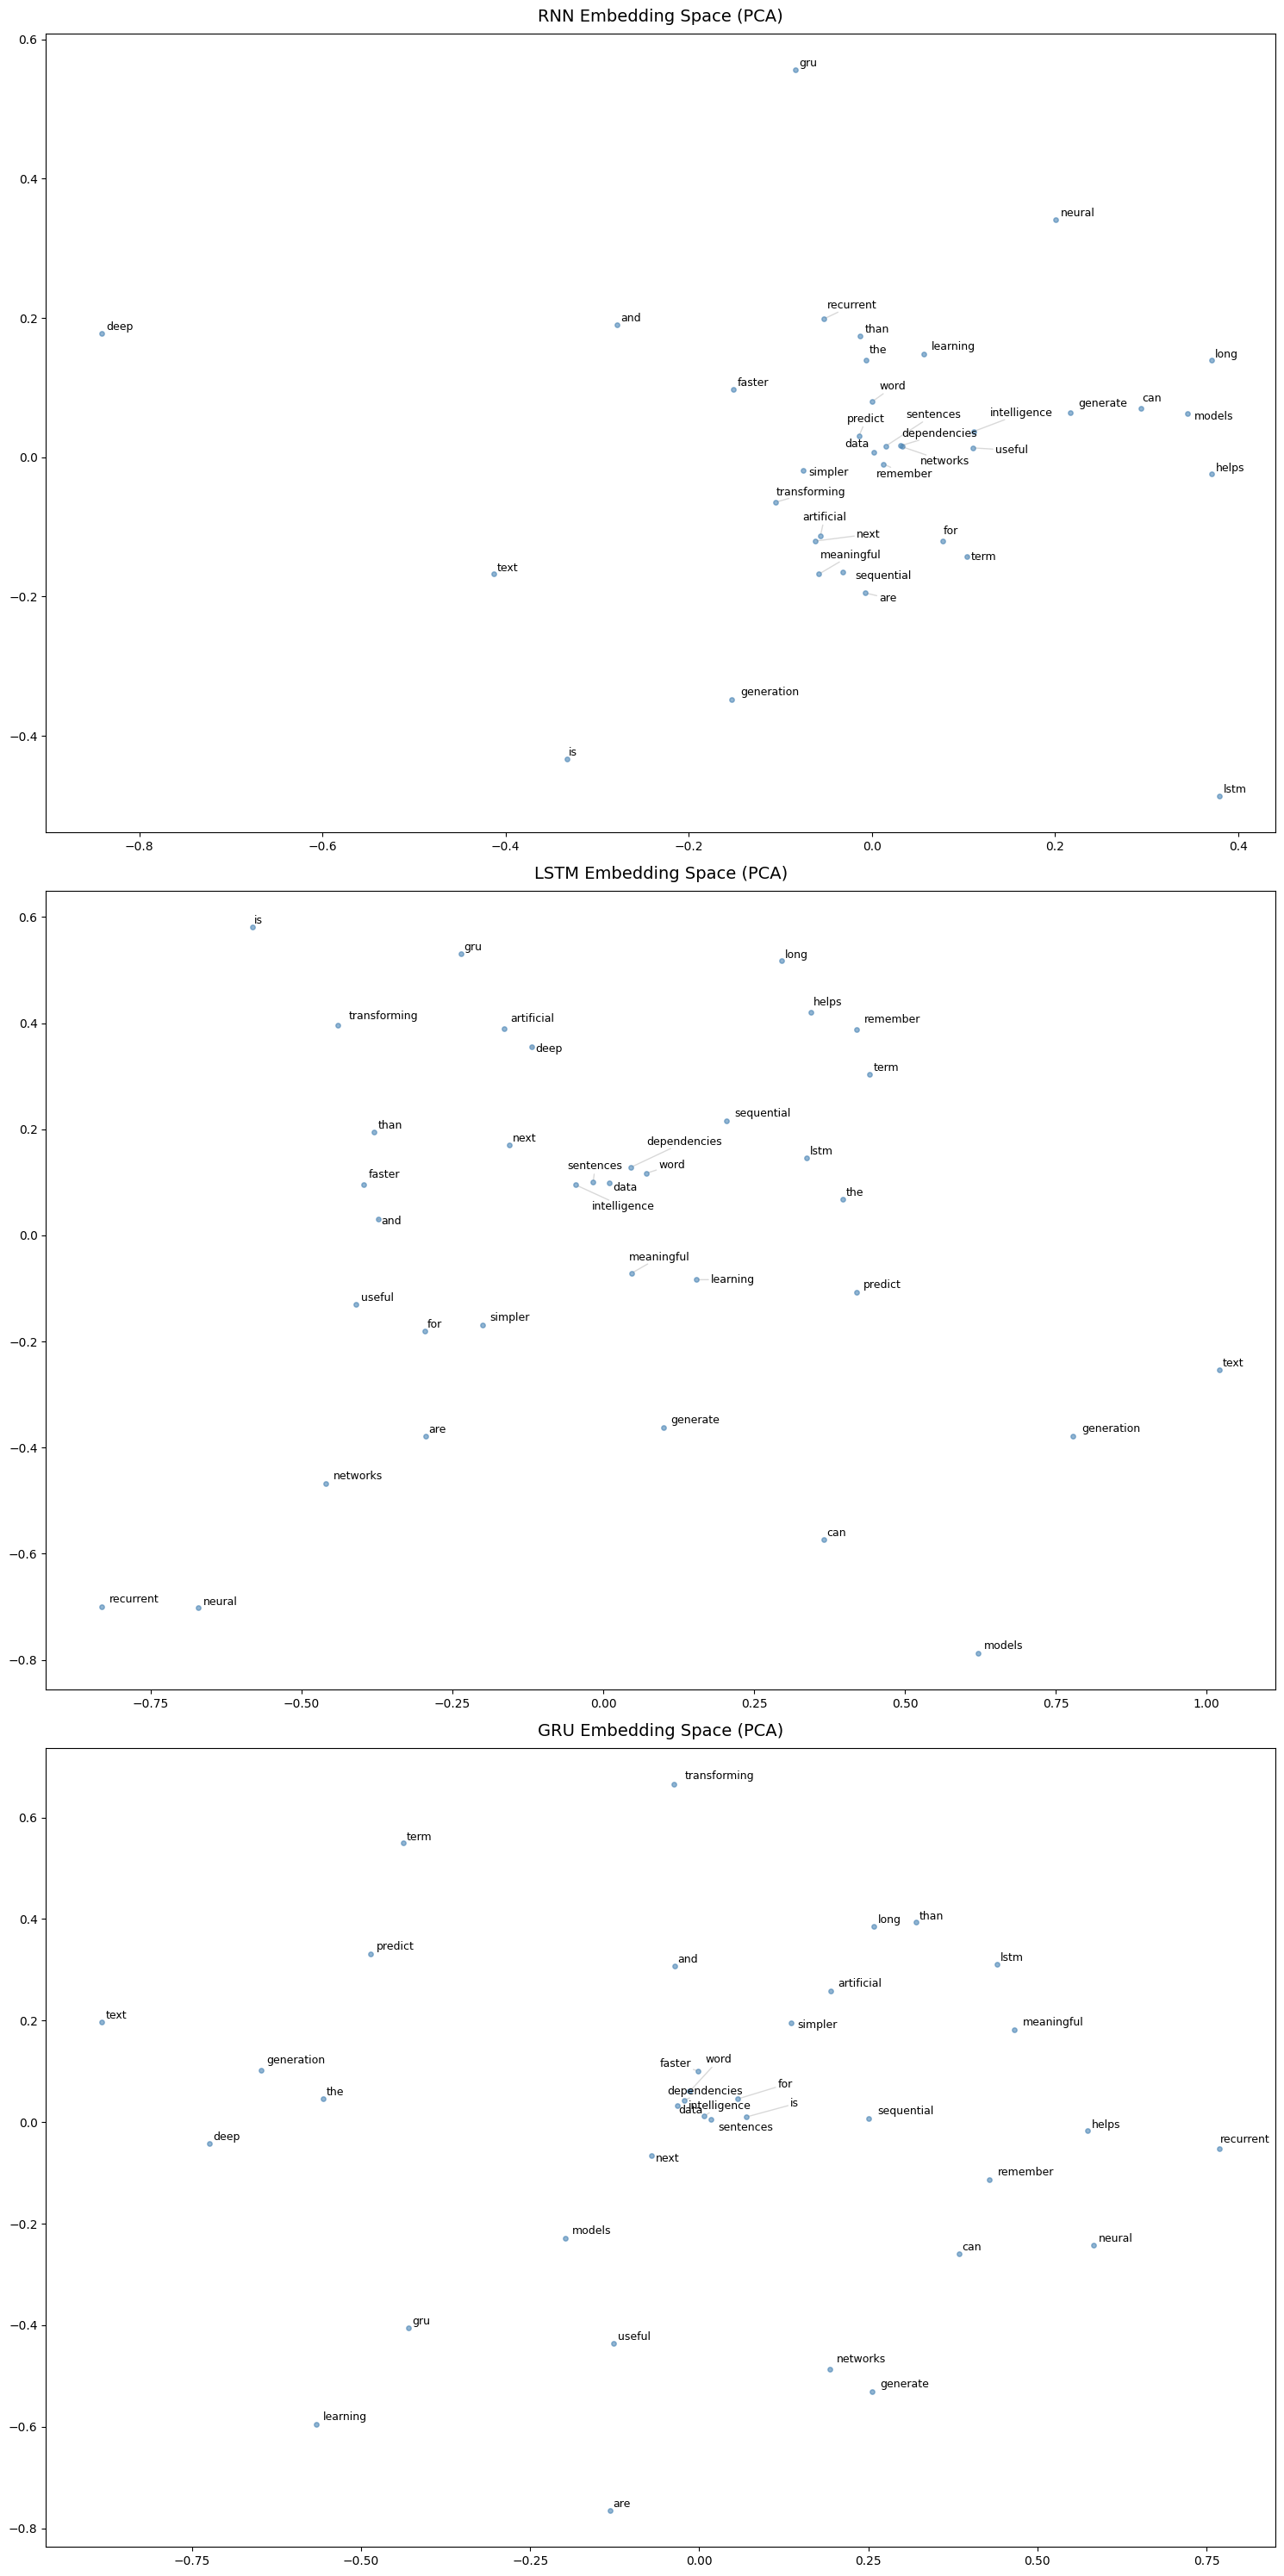

In [25]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

models_list = [('RNN', rnn_model), ('LSTM', lstm_model), ('GRU', gru_model)]

# 1. Changed layout to 3 rows, 1 column and expanded size to 15x30
fig, axes = plt.subplots(3, 1, figsize=(15, 30))

for ax, (name, model) in zip(axes, models_list):
    emb_weights = get_embedding_weights(model)
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb_weights[1:])

    # 2. Made points slightly transparency (alpha) to see density
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], color='steelblue', alpha=0.6, s=15)

    # 3. Store texts in a list to optimize their positions together
    texts = []
    for word, idx in tokenizer.word_index.items():
        if idx - 1 < len(emb_2d):
            t = ax.text(emb_2d[idx - 1, 0], emb_2d[idx - 1, 1], word, fontsize=9)
            texts.append(t)

    # 4. Automatically push text labels away from each other and data points
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', alpha=0.3))

    ax.set_title(f"{name} Embedding Space (PCA)", fontsize=14, pad=10)

plt.tight_layout()
plt.show()


# 🔢 Inspect Next-Word Probabilities
Instead of only seeing the single word each model picks, it's informative to look at its **top-5 candidate words and their probabilities** for the same seed text — this shows how confident (or uncertain) each architecture really is.

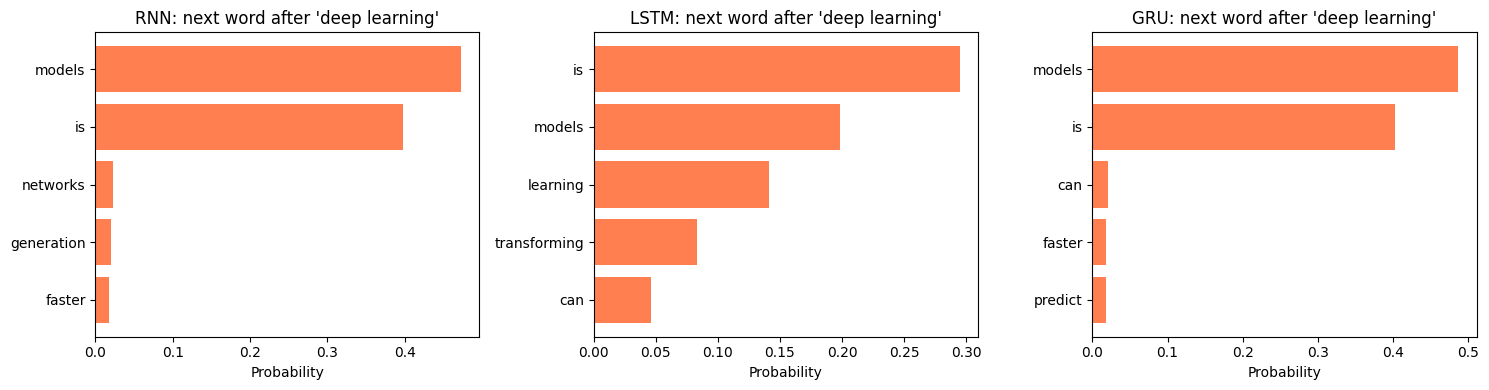

In [20]:
def top_k_predictions(model, seed_text, k=5):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    probs = model.predict(token_list, verbose=0)[0]
    top_indices = np.argsort(probs)[-k:][::-1]
    return [(tokenizer.index_word.get(i, '?'), probs[i]) for i in top_indices]

seed = "deep learning"
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (name, model) in zip(axes, models_list):
    top_preds = top_k_predictions(model, seed, k=5)
    words, probs = zip(*top_preds)
    ax.barh(words, probs, color='coral')
    ax.set_title(f"{name}: next word after '{seed}'")
    ax.set_xlabel("Probability")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# 💾 Save Trained Models
Saving each model lets you reload it later (e.g. in a separate inference notebook or a small demo app) without retraining.

In [21]:
rnn_model.save("rnn_text_gen_model.keras")
lstm_model.save("lstm_text_gen_model.keras")
gru_model.save("gru_text_gen_model.keras")
print("All three models saved in .keras format.")
print("Reload any of them with: tf.keras.models.load_model('filename.keras')")

All three models saved in .keras format.
Reload any of them with: tf.keras.models.load_model('filename.keras')


# 📚 Student Learning Tasks

### ✅ Beginner
1. Replace the corpus with your own paragraph
2. Increase the embedding dimension (32 → 64)
3. Change hidden units 64 → 128
4. Generate 10 words instead of 5

### 🟡 Intermediate
5. Set `USE_EXTENDED_CORPUS = True` and compare results to the original corpus
6. Try `Bidirectional(LSTM(64))` — does it help on this task, and why or why not for *next-word* prediction specifically?
7. Add a validation split and `EarlyStopping(monitor='val_loss', ...)` once your corpus is big enough to support one
8. Plot perplexity over training, not just at the end

### 🔴 Advanced
9. Stack two recurrent layers (e.g. `LSTM(64, return_sequences=True)` → `LSTM(64)`) and compare parameter count vs. performance gain
10. Replace word-level tokenization with character-level tokenization — how does vocabulary size and generation quality change?
11. Implement beam search decoding and compare it against greedy and temperature sampling
12. Train the same architectures on a much larger public corpus (e.g. a public-domain book) and see whether the RNN-vs-LSTM-vs-GRU gap widens or narrows

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory, and the vanishing gradient problem shows up as slower/less stable convergence on anything but very short sequences
- **LSTM** captures long-range grammar dependencies better, at the cost of roughly 4x the gate parameters of a SimpleRNN of the same hidden size
- **GRU** gives similar performance to LSTM with fewer gates (≈3x parameters instead of 4x) and typically faster training
- On a tiny corpus like this one, all three models will tend to **overfit and memorize** — that's not a bug, it's exactly what you'd expect, and it's why perplexity and generation quality both look "too good" here
- **Temperature sampling** matters as much as architecture choice for how natural generated text feels — greedy decoding from any of these three models can loop or repeat
- This notebook helps you understand **sequence modeling mathematically and practically**, including the metrics (parameters, training time, perplexity) used to compare architectures in practice, not just their generated output

Check the `model_stats` table above for the full side-by-side numbers.